Fontes: https://en.wikipedia.org/wiki/Ensemble_learning

https://hub.asimov.academy/blog/o-que-e-ensemble-learning/

Vamos imaginar que você precisa tomar uma decisão importante: investir em uma ação na bolsa. Você poderia:

1. **Consultar apenas um especialista** - E se ele estiver tendo um dia ruim ou tiver um viés?

2. **Consultar vários especialistas e combinar suas opiniões** - provavelmente mais confiável, mas mais rápido

É exatamente essa ideia com **Ensemble Learning**!

Até agora, estudamos vários algoritmos de classificação: KNN, Naive Bayes, Regressão Logística, Árvores de Decisão, SVM. Cada um tem seus pontos fortes e fracos:

- **Árvores de Decisão**: Fáceis de interpretar, mas propensas a overfitting
- **KNN**: Simples e eficaz, mas sensível a ruído e features irrelevantes
- **Naive Bayes**: Rápido e eficiente, mas assume independência entre features
- **Regressão Logística**: Interpretável e estável, mas assume relação linear

**Mas o que aconteceria se pudessemos unir eles?**

### 3.6.1 O Problema: Por que um único modelo não é suficiente?

Vamos fazer um experimento. Imagine que você está construindo um modelo para prever se um cliente vai cancelar sua assinatura (churn).

**Cenário 1: Uma única Árvore de Decisão**

Você treina uma árvore de decisão e obtém 85% de acurácia no conjunto de teste. Ótimo, certo?

Mas espera... olha o que acontece se treinar a mesma árvore com pequenas variações nos dados:

- **Tentativa 1**: 85% de acurácia
- **Tentativa 2**: 82% de acurácia (removemos 5% dos dados aleatoriamente)
- **Tentativa 3**: 88% de acurácia (diferentes dados de treino)
- **Tentativa 4**: 79% de acurácia
- **Tentativa 5**: 86% de acurácia

**Problemas:**

1. **Alta Variância**: Pequenas mudanças nos dados causam grandes variações no modelo
2. **Overfitting**: O modelo pode estar "decorando" os dados de treino
3. **Instabilidade**: Não podemos confiar plenamente em suas previsões

**A Solução dos Ensembles:**

Em vez de confiar em uma única árvore, será que faz sentido treinar várias árvores diferentes e combinar suas previsões?

- Se 8 de 10 árvores dizem "cliente vai cancelar", provavelmente ele vai...

### 3.6.2 Bagging: Bootstrap Aggregating

**O que é Bagging?**

Bagging (Bootstrap Aggregating) é como pedir a opinião de várias pessoas que estudaram o mesmo assunto, mas com materiais ligeiramente diferentes.

**A Ideia:**

1. Pegamos nosso conjunto de dados original
2. Criamos várias "versões" diferentes dele (amostras bootstrap)
3. Treinamos um modelo em cada versão
4. Combinamos as previsões

**Bootstrap?**

Bootstrap é uma técnica de reamostragem com substituição. Imagine que você tem uma sacola com 100 bolas numeradas:

- Você retira uma bola, anota o número, e **devolve a bola** na sacola
- Repete isso 100 vezes
- Resultado: alguns números aparecem várias vezes, outros não aparecem

Isso cria uma versão "similar, mas diferente" do conjunto original! Retornaremos nisso

#### 3.6.2.1 Intuição do Bagging

Vamos usar o dataset do Titanic (achei um bom dataset) para entender o Bagging na prática.

**Mesmo Problema**: Prever se um passageiro sobreviveu ao naufrágio.

**Abordagem com uma única Árvore de Decisão:**
- Treina em todos os dados
- Pode fazer overfitting
- Instável com mudanças nos dados

**Abordagem com Bagging:**
- Cria 10 versões diferentes do dataset (bootstrap)
- Treina uma árvore em cada versão
- Cada árvore vota: "Sobreviveu" ou "Não sobreviveu"
- Decisão final: maioria dos votos

Vamos ver isso acontecer!

In [8]:
# =======================================================
# IMPORTANDO AS BIBLIOTECAS
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Configuração de visualização (ignora, estou testando novas visualizações)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# =======================================================
# Carregando o Dataset do Titanic
# =======================================================

import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "yasserh/titanic-dataset",
    "Titanic-Dataset.csv",
    pandas_kwargs={"encoding": "latin", "usecols": [1, 2, 4, 5]}
)

# Pré-processamento
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Age'] = df['Age'].fillna(df['Age'].mean())

X = df[['Pclass', 'Sex', 'Age']].values
y = df['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Tamanho do conjunto de treino: {len(X_train)}")
print(f"Tamanho do conjunto de teste: {len(X_test)}")

Tamanho do conjunto de treino: 712
Tamanho do conjunto de teste: 179


In [12]:
# =======================================================
# Passo 1: Treinar uma ÚNICA Árvore de Decisão
# =======================================================

single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

y_pred_single = single_tree.predict(X_test)
metrics_single = classification_report(y_test, y_pred_single)

print(f"Métricas de uma única árvore:\n{metrics_single}")

# Vamos ver como essa árvore se comporta com diferentes amostras
print("\nTestando estabilidade (treinando em diferentes subconjuntos):")
accuracies = []

for i in range(10):
    # Criar uma amostra bootstrap
    indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train[indices]
    y_boot = y_train[indices]
    
    # Treinar árvore
    tree = DecisionTreeClassifier(random_state=i)
    tree.fit(X_boot, y_boot)
    
    # Avaliar
    acc = accuracy_score(y_test, tree.predict(X_test))
    accuracies.append(acc)
    print(f"Árvore {i+1}: {acc*100:.2f}%")

print(f"\nMédia: {np.mean(accuracies)*100:.2f}%")
print(f"Desvio padrão: {np.std(accuracies)*100:.2f}%")
print(f"\nInterpretação: A acurácia varia entre {min(accuracies)*100:.2f}% e {max(accuracies)*100:.2f}%")
print("nota: Cada árvore 'aprendeu' algo diferente.")

Métricas de uma única árvore:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.68      0.71        74

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.77       179


Testando estabilidade (treinando em diferentes subconjuntos):
Árvore 1: 79.33%
Árvore 2: 79.89%
Árvore 3: 77.65%
Árvore 4: 79.33%
Árvore 5: 73.18%
Árvore 6: 81.01%
Árvore 7: 77.65%
Árvore 8: 79.33%
Árvore 9: 80.45%
Árvore 10: 78.77%

Média: 78.66%
Desvio padrão: 2.09%

Interpretação: A acurácia varia entre 73.18% e 81.01%
nota: Cada árvore 'aprendeu' algo diferente.


In [14]:
# =======================================================
# Passo 2: Implementar Bagging Manualmente
# =======================================================

n_estimators = 10  # Número de árvores no ensemble

# Armazenar os modelos
models = []
predictions = []

print("Treinando ensemble com Bagging...")
for i in range(n_estimators):
    # 1. Criar amostra bootstrap
    indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train[indices]
    y_boot = y_train[indices]
    
    # 2. Treinar modelo na amostra bootstrap
    tree = DecisionTreeClassifier(random_state=i)
    tree.fit(X_boot, y_boot)
    models.append(tree)
    
    # 3. Fazer previsões
    pred = tree.predict(X_test)
    predictions.append(pred)
    
    print(f"Árvore {i+1} treinada em {len(np.unique(indices))} amostras únicas (de {len(X_train)} possíveis)")


predictions = np.array(predictions)

print(f"\nShape das previsões: {predictions.shape}")
print(f"({n_estimators} árvores, {len(X_test)} amostras de teste)")

# =======================================================
# Passo 3: Combinar previsões por votação majoritária
# =======================================================

# Para cada amostra de teste, contar os votos
final_predictions = []

for i in range(len(X_test)):
    votes = predictions[:, i]  # Votos de todas as árvores para a amostra i
    # Votação majoritária
    prediction = np.bincount(votes).argmax()
    final_predictions.append(prediction)

final_predictions = np.array(final_predictions)

# Avaliar
metrics_bagging = classification_report(y_test, final_predictions)

print(f"\n{'='*50}")
print(f"RESULTADOS:")
print(f"{'='*50}")
print(f"Métricas com Bagging ({n_estimators} árvores):\n{metrics_bagging}")
metric = accuracy_score(y_test, final_predictions)
print(f"Acurácia com Bagging ({n_estimators} árvores): {metric*100:.2f}%")
print(f"Melhoria: {(metric - accuracy_score(y_test, y_pred_single))*100:.2f} pontos percentuais")

Treinando ensemble com Bagging...
Árvore 1 treinada em 450 amostras únicas (de 712 possíveis)
Árvore 2 treinada em 462 amostras únicas (de 712 possíveis)
Árvore 3 treinada em 453 amostras únicas (de 712 possíveis)
Árvore 4 treinada em 469 amostras únicas (de 712 possíveis)
Árvore 5 treinada em 458 amostras únicas (de 712 possíveis)
Árvore 6 treinada em 447 amostras únicas (de 712 possíveis)
Árvore 7 treinada em 446 amostras únicas (de 712 possíveis)
Árvore 8 treinada em 445 amostras únicas (de 712 possíveis)
Árvore 9 treinada em 436 amostras únicas (de 712 possíveis)
Árvore 10 treinada em 451 amostras únicas (de 712 possíveis)

Shape das previsões: (10, 179)
(10 árvores, 179 amostras de teste)

RESULTADOS:
Métricas com Bagging (10 árvores):
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       105
           1       0.82      0.69      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.

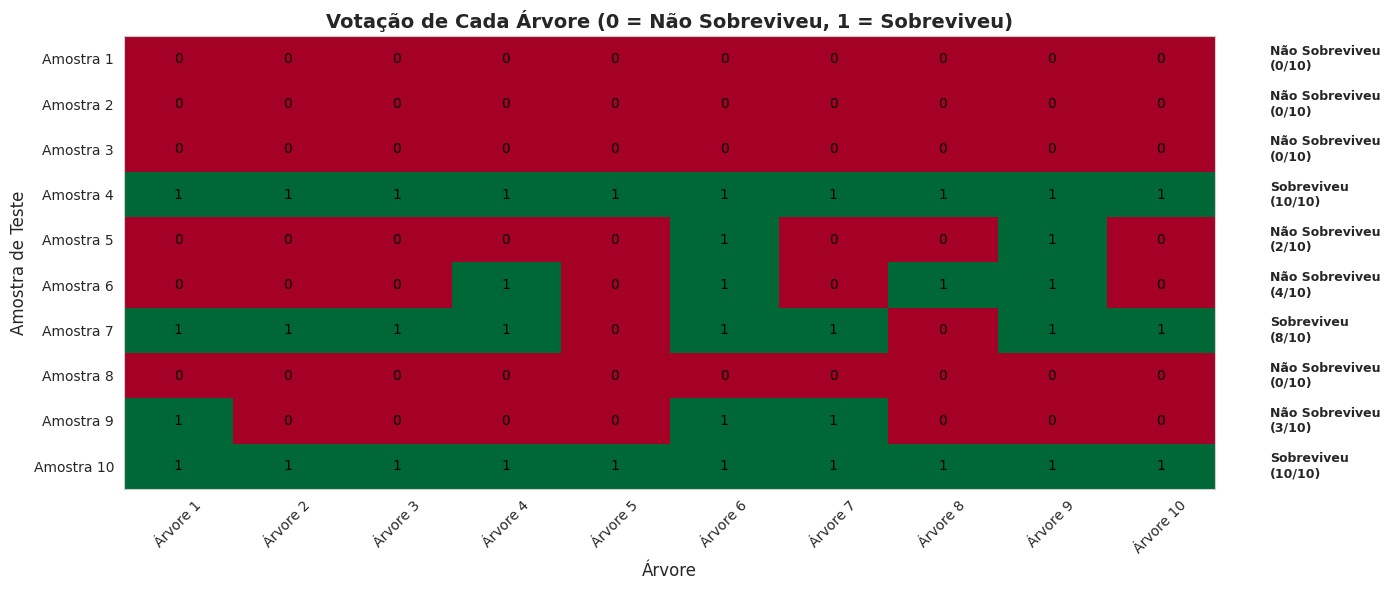


Interpretação:
- Verde: Árvore previu 'Sobreviveu' (1)
- Vermelho: Árvore previu 'Não Sobreviveu' (0)
- Decisão final: maioria dos votos


In [23]:
# =======================================================
# Visualização: Como cada árvore vota
# =======================================================

# Vamos ver as previsões para as primeiras 10 amostras de teste
n_samples_to_show = 10

fig, ax = plt.subplots(figsize=(14, 6))

# Criar matriz de votos
vote_matrix = predictions[:, :n_samples_to_show].T

# Plotar heatmap
im = ax.imshow(vote_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Configurar eixos
ax.set_xlabel('Árvore', fontsize=12)
ax.set_ylabel('Amostra de Teste', fontsize=12)
ax.set_title('Votação de Cada Árvore (0 = Não Sobreviveu, 1 = Sobreviveu)', fontsize=14, fontweight='bold')
ax.set_xticks(range(n_estimators))
ax.set_xticklabels([f'Árvore {i+1}' for i in range(n_estimators)], rotation=45)
ax.set_yticks(range(n_samples_to_show))
ax.set_yticklabels([f'Amostra {i+1}' for i in range(n_samples_to_show)])
ax.grid(False)

# Adicionar valores nas células
for i in range(n_samples_to_show):
    for j in range(n_estimators):
        text = ax.text(j, i, int(vote_matrix[i, j]), 
                      ha="center", va="center", color="black", fontsize=10)


# Adicionar informação sobre a votação final
for i in range(n_samples_to_show):
    votes = vote_matrix[i]
    final_vote = "Sobreviveu" if np.sum(votes) > n_estimators/2 else "Não Sobreviveu"
    vote_count = int(np.sum(votes))
    ax.text(n_estimators, i, f'{final_vote}\n({vote_count}/{n_estimators})', 
           ha="left", va="center", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nInterpretação:")
print("- Verde: Árvore previu 'Sobreviveu' (1)")
print("- Vermelho: Árvore previu 'Não Sobreviveu' (0)")
print("- Decisão final: maioria dos votos")

#### 3.X.2.2 Formulação Formal do Bagging

**Entrada:**

1. Conjunto de treinamento: $D = \{(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), ..., (x^{(n)}, y^{(n)})\}$

2. Algoritmo de aprendizado base $\mathcal{A}$ (e.g., Árvore de Decisão)

3. Número de modelos no ensemble: $T$

**Processamento:**

Para cada modelo $t = 1, 2, ..., T$:

1. **Criar amostra bootstrap** $D_t$:
   - Amostrar $n$ exemplos de $D$ com substituição
   - Aproximadamente 63.2% das amostras originais aparecem em $D_t$
   - As amostras restantes (~36.8%) são chamadas de "out-of-bag" (OOB)

2. **Treinar modelo base**:
   - $h_t = \mathcal{A}(D_t)$
   - Cada modelo $h_t$ é treinado independentemente

**Saída - Predição:**

Para uma nova amostra $x^o$:

- **Classificação** (votação majoritária):

$$\hat{y} = \text{mode}\{h_1(x^o), h_2(x^o), ..., h_T(x^o)\}$$

- **Regressão** (média):

$$\hat{y} = \frac{1}{T}\sum_{t=1}^{T}h_t(x^o)$$

**Propriedades Importantes:**

1. **Redução de Variância**: 
   - Se os modelos base têm variância $\sigma^2$, a variância do ensemble é aproximadamente $\frac{\sigma^2}{T}$ (assumindo independência)
   - Na prática, há correlação entre modelos, mas ainda assim a variância é reduzida

2. **Out-of-Bag Error (OOB)**:
   - Para cada amostra de treino, podemos usar os modelos que NÃO a viram no treino para estimar o erro
   - Isso fornece uma estimativa de validação "gratuita" sem precisar de um conjunto de validação separado

3. **Bias-Variance Tradeoff**:
   - Bagging reduz principalmente a **variância** sem aumentar significativamente o **bias**
   - Funciona melhor com modelos de baixo bias e alta variância (como árvores profundas)

#### 3.X.2.3 Desafio: Implementar Bagging do Zero

Agora é sua vez! Implemente uma classe `BaggingClassifier` que funcione com qualquer classificador base.

**Requisitos:**

1. Deve aceitar qualquer classificador como base (DecisionTree, KNN, etc.)
2. Criar amostras bootstrap
3. Treinar múltiplos modelos
4. Combinar previsões por votação
5. Calcular OOB error (desafio extra!)

In [ ]:
from sklearn.base import clone

class BaggingClassifier:
    def __init__(self, base_estimator, n_estimators=10, random_state=None):
        """
        Inicializa o BaggingClassifier
        
        Parâmetros:
        -----------
        base_estimator: classificador base (e.g., DecisionTreeClassifier())
        n_estimators: número de modelos no ensemble
        random_state: seed para reprodutibilidade
        """
        pass
    
    def _create_bootstrap_sample(self, X, y):
        """
        Cria uma amostra bootstrap de X e y
        
        Retorna:
        --------
        X_boot, y_boot: amostra bootstrap
        oob_indices: índices das amostras out-of-bag
        """
        pass
    
    def fit(self, X, y):
        """
        Treina o ensemble
        
        Processo:
        1. Para cada estimador:
           a. Criar amostra bootstrap
           b. Clonar o estimador base
           c. Treinar o clone na amostra bootstrap
           d. Armazenar o modelo e os índices OOB
        """
        pass
    
    def predict(self, X):
        """
        Faz previsões usando votação majoritária
        
        Retorna:
        --------
        y_pred: array de previsões
        """
        pass
    
    def score(self, X, y):
        """
        Calcula a acurácia do modelo
        """
        pass
    
    def oob_score(self):
        """
        DESAFIO EXTRA: Calcular o OOB error
        
        Para cada amostra de treino:
        - Usar apenas os modelos que NÃO a viram no treino
        - Fazer votação com esses modelos
        - Comparar com o label verdadeiro
        
        Retorna:
        --------
        oob_accuracy: acurácia calculada nas amostras OOB
        """
        pass

#### 3.X.2.4 Usando Sklearn: BaggingClassifier e Random Forest

Agora vamos usar as implementações otimizadas do scikit-learn!

In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# =======================================================
# 1. BaggingClassifier com Árvores de Decisão
# =======================================================

bagging_tree = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42,
    oob_score=True  # Calcular OOB score
)

bagging_tree.fit(X_train, y_train)

print("="*60)
print("BAGGING COM ÁRVORES DE DECISÃO")
print("="*60)
print(f"Acurácia no teste: {bagging_tree.score(X_test, y_test)*100:.2f}%")
print(f"OOB Score: {bagging_tree.oob_score_*100:.2f}%")
print(f"Número de estimadores: {bagging_tree.n_estimators}")

# =======================================================
# 2. Random Forest (Bagging + Feature Randomness)
# =======================================================

# Random Forest é um tipo especial de Bagging que:
# - Usa árvores de decisão como base
# - Adiciona aleatoriedade na seleção de features

random_forest = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    oob_score=True
)

random_forest.fit(X_train, y_train)

print("\n" + "="*60)
print("RANDOM FOREST (Bagging + Feature Randomness)")
print("="*60)
print(f"Acurácia no teste: {random_forest.score(X_test, y_test)*100:.2f}%")
print(f"OOB Score: {random_forest.oob_score_*100:.2f}%")

# Feature importance
feature_names = ['Pclass', 'Sex', 'Age']
importances = random_forest.feature_importances_
print("\nImportância das features:")
for name, importance in zip(feature_names, importances):
    print(f"  {name}: {importance*100:.2f}%")

# =======================================================
# 3. Bagging com outros classificadores
# =======================================================

print("\n" + "="*60)
print("BAGGING COM DIFERENTES CLASSIFICADORES BASE")
print("="*60)

# KNN
bagging_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=50,
    random_state=42
)
bagging_knn.fit(X_train, y_train)
print(f"\nBagging + KNN: {bagging_knn.score(X_test, y_test)*100:.2f}%")

# Naive Bayes
bagging_nb = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=50,
    random_state=42
)
bagging_nb.fit(X_train, y_train)
print(f"Bagging + Naive Bayes: {bagging_nb.score(X_test, y_test)*100:.2f}%")

In [ ]:
# =======================================================
# Parâmetros Importantes do BaggingClassifier
# =======================================================

# n_estimators: número de modelos base
# max_samples: número/proporção de amostras para cada bootstrap
# max_features: número/proporção de features para cada modelo
# bootstrap: se True, usa bootstrap; se False, usa todo dataset
# oob_score: se True, calcula OOB score

configs = [
    {'n_estimators': 10, 'max_samples': 1.0, 'max_features': 1.0},
    {'n_estimators': 50, 'max_samples': 0.8, 'max_features': 1.0},
    {'n_estimators': 100, 'max_samples': 1.0, 'max_features': 0.8},
    {'n_estimators': 50, 'max_samples': 0.7, 'max_features': 0.7},
]

print("Testando diferentes configurações:\n")
for i, config in enumerate(configs, 1):
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        **config,
        random_state=42,
        oob_score=True
    )
    bag.fit(X_train, y_train)
    
    print(f"{i}. n_estimators={config['n_estimators']}, "
          f"max_samples={config['max_samples']}, "
          f"max_features={config['max_features']}")
    print(f"   Acurácia: {bag.score(X_test, y_test)*100:.2f}%")
    print(f"   OOB Score: {bag.oob_score_*100:.2f}%\n")

**💡 Dica: Random Forest vs Bagging**

- **BaggingClassifier com árvores**: Cada árvore vê TODAS as features em cada divisão
- **RandomForest**: Cada divisão da árvore vê apenas um subconjunto aleatório de features

Por que isso importa?
- Random Forest cria árvores mais **decorrelacionadas**
- Resultado: geralmente melhor performance que Bagging puro
- Trade-off: um pouco mais de bias, mas muito menos variância

### 3.X.3 Boosting: Aprendizado Sequencial

**O que é Boosting?**

Se Bagging é como pedir a opinião de vários especialistas **independentes**, Boosting é como ter uma **equipe que aprende com os erros uns dos outros sequencialmente**.

**A Diferença Fundamental:**

- **Bagging**: Modelos treinados em **paralelo**, independentemente
  - "Todos vocês, estudem o material e me digam o que acham"

- **Boosting**: Modelos treinados em **sequência**, cada um focando nos erros do anterior
  - "Você 1, estude tudo. Você 2, foque no que o 1 errou. Você 3, foque no que os anteriores erraram..."

**A Intuição:**

1. Treinar um modelo "fraco" (weak learner)
2. Identificar em quais amostras ele errou
3. Dar mais **peso/atenção** a essas amostras difíceis
4. Treinar um novo modelo focado nelas
5. Repetir o processo
6. Combinar todos os modelos, dando mais peso aos melhores

É como estudar para uma prova: você dedica mais tempo aos tópicos que errou no simulado!

#### 3.X.3.1 Intuição do AdaBoost (Adaptive Boosting)

AdaBoost foi um dos primeiros e mais populares algoritmos de boosting. Vamos entender como funciona!

**O Processo:**

1. **Início**: Todas as amostras têm peso igual (e.g., 1/n cada)

2. **Treinar modelo 1**: 
   - Treina em todas as amostras
   - Identifica quais errou

3. **Ajustar pesos**:
   - ↑ Aumenta peso das amostras que errou
   - ↓ Diminui peso das que acertou

4. **Treinar modelo 2**:
   - Agora "presta mais atenção" nas amostras difíceis
   - Tem que acertar as que o modelo 1 errou

5. **Repetir** o processo T vezes

6. **Combinar**: Cada modelo tem um peso baseado em sua acurácia
   - Modelos melhores têm mais influência na decisão final

Vamos ver isso na prática!

In [ ]:
# =======================================================
# Simulação Visual do AdaBoost
# =======================================================

# Vamos simular como os pesos das amostras mudam ao longo do boosting

# Criar um dataset simples 2D para visualizar
from sklearn.datasets import make_classification

X_viz, y_viz = make_classification(
    n_samples=100, 
    n_features=2, 
    n_redundant=0, 
    n_informative=2,
    n_clusters_per_class=1,
    flip_y=0.1,  # Adiciona um pouco de ruído
    random_state=42
)

# Treinar AdaBoost passo a passo
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# Inicializar pesos uniformes
weights = np.ones(len(X_viz)) / len(X_viz)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

n_iterations = 6
models = []
alphas = []

for i in range(n_iterations):
    # Treinar um modelo fraco (árvore com profundidade 1 - stump)
    weak_learner = DecisionTreeClassifier(max_depth=1, random_state=i)
    weak_learner.fit(X_viz, y_viz, sample_weight=weights)
    
    # Fazer previsões
    predictions = weak_learner.predict(X_viz)
    
    # Identificar erros
    incorrect = predictions != y_viz
    
    # Calcular erro ponderado
    error = np.sum(weights[incorrect]) / np.sum(weights)
    
    # Calcular alpha (peso do modelo)
    alpha = 0.5 * np.log((1 - error) / max(error, 1e-10))
    
    # Atualizar pesos
    weights = weights * np.exp(alpha * incorrect * ((predictions == y_viz) * 2 - 1))
    weights = weights / np.sum(weights)  # Normalizar
    
    models.append(weak_learner)
    alphas.append(alpha)
    
    # Visualizar
    ax = axes[i]
    
    # Plotar pontos com tamanho proporcional ao peso
    scatter = ax.scatter(
        X_viz[:, 0], X_viz[:, 1], 
        c=y_viz, 
        s=weights * 5000,  # Tamanho proporcional ao peso
        alpha=0.6, 
        cmap='RdYlGn',
        edgecolors='black',
        linewidth=1
    )
    
    # Adicionar círculo vermelho nas amostras erradas
    incorrect_samples = X_viz[incorrect]
    if len(incorrect_samples) > 0:
        ax.scatter(
            incorrect_samples[:, 0], 
            incorrect_samples[:, 1], 
            s=300, 
            facecolors='none', 
            edgecolors='red', 
            linewidth=3,
            label='Erros'
        )
    
    ax.set_title(f'Iteração {i+1}\nErro: {error:.3f}, Alpha: {alpha:.3f}', 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Evolução dos Pesos das Amostras no AdaBoost\n(Tamanho do ponto = peso da amostra)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretação:")
print("- Pontos MAIORES = maior peso (modelo foca mais neles)")
print("- Círculo VERMELHO = modelo errou essa amostra")
print("- A cada iteração, os erros ganham mais peso")

#### 3.X.3.2 Formulação Formal do AdaBoost

**Entrada:**

1. Conjunto de treinamento: $D = \{(x^{(1)}, y^{(1)}), ..., (x^{(n)}, y^{(n)})\}$ onde $y^{(i)} \in \{-1, +1\}$

2. Algoritmo de aprendizado fraco $\mathcal{A}$

3. Número de iterações: $T$

**Processamento:**

**Inicialização:**
- Pesos uniformes: $w^{(1)}_i = \frac{1}{n}$ para $i = 1, ..., n$

**Para cada iteração** $t = 1, 2, ..., T$:

1. **Treinar modelo fraco**:
   - $h_t = \mathcal{A}(D, w^{(t)})$
   - Cada amostra $(x^{(i)}, y^{(i)})$ tem peso $w^{(t)}_i$

2. **Calcular erro ponderado**:
   
   $$\epsilon_t = \sum_{i=1}^{n} w^{(t)}_i \cdot \mathbb{I}(h_t(x^{(i)}) \neq y^{(i)})$$
   
   onde $\mathbb{I}$ é a função indicadora (1 se erro, 0 se acerto)

3. **Calcular peso do modelo** (influência na predição final):
   
   $$\alpha_t = \frac{1}{2}\ln\left(\frac{1-\epsilon_t}{\epsilon_t}\right)$$
   
   - Se $\epsilon_t$ é pequeno (modelo bom) → $\alpha_t$ é grande
   - Se $\epsilon_t \approx 0.5$ (chute aleatório) → $\alpha_t \approx 0$

4. **Atualizar pesos das amostras**:
   
   $$w^{(t+1)}_i = w^{(t)}_i \cdot \exp(-\alpha_t \cdot y^{(i)} \cdot h_t(x^{(i)}))$$
   
   Simplificando:
   - Se $h_t$ acerta $(y^{(i)} = h_t(x^{(i)}))$: peso diminui (multiplicado por $e^{-\alpha_t}$)
   - Se $h_t$ erra $(y^{(i)} \neq h_t(x^{(i)}))$: peso aumenta (multiplicado por $e^{\alpha_t}$)

5. **Normalizar pesos**:
   
   $$w^{(t+1)}_i = \frac{w^{(t+1)}_i}{\sum_{j=1}^{n}w^{(t+1)}_j}$$

**Saída - Predição:**

Para uma nova amostra $x^o$:

$$H(x^o) = \text{sign}\left(\sum_{t=1}^{T}\alpha_t \cdot h_t(x^o)\right)$$

- Votação ponderada: modelos melhores ($\alpha_t$ maior) têm mais influência
- $\text{sign}()$ retorna +1 ou -1 (a classe final)

#### 3.X.3.3 Usando Sklearn: AdaBoost e Gradient Boosting

Vamos explorar as principais implementações de Boosting no scikit-learn!

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# =======================================================
# 1. AdaBoost
# =======================================================

ada_boost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # Stumps
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada_boost.fit(X_train, y_train)

print("="*60)
print("ADABOOST")
print("="*60)
print(f"Acurácia no teste: {ada_boost.score(X_test, y_test)*100:.2f}%")

# Pesos dos estimadores
print(f"\nPrimeiros 5 pesos dos modelos (alpha):")
print(ada_boost.estimator_weights_[:5])

# =======================================================
# 2. Gradient Boosting
# =======================================================

# Gradient Boosting é uma generalização do AdaBoost
# Em vez de ajustar pesos, ele ajusta os resíduos (erros) diretamente

gradient_boost = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boost.fit(X_train, y_train)

print("\n" + "="*60)
print("GRADIENT BOOSTING")
print("="*60)
print(f"Acurácia no teste: {gradient_boost.score(X_test, y_test)*100:.2f}%")

# Feature importance
feature_names = ['Pclass', 'Sex', 'Age']
importances = gradient_boost.feature_importances_
print("\nImportância das features:")
for name, importance in zip(feature_names, importances):
    print(f"  {name}: {importance*100:.2f}%")

# =======================================================
# 3. Comparação: Bagging vs Boosting
# =======================================================

from sklearn.ensemble import RandomForestClassifier

models = {
    'Single Tree': DecisionTreeClassifier(random_state=42),
    'Bagging (Random Forest)': RandomForestClassifier(n_estimators=50, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42)
}

print("\n" + "="*60)
print("COMPARAÇÃO DE MODELOS")
print("="*60)

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"{name:25s}: {acc*100:.2f}%")

In [ ]:
# =======================================================
# Parâmetros Importantes do Gradient Boosting
# =======================================================

# n_estimators: número de árvores
# learning_rate: taxa de aprendizado (shrinkage)
#   - Valores menores = mais árvores necessárias, mas melhor generalização
# max_depth: profundidade máxima de cada árvore
# subsample: fração de amostras usadas para treinar cada árvore
#   - < 1.0 = Stochastic Gradient Boosting (reduz overfitting)

configs = [
    {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 1.0},
    {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8},
]

print("Testando diferentes configurações de Gradient Boosting:\n")
for i, config in enumerate(configs, 1):
    gb = GradientBoostingClassifier(**config, random_state=42)
    gb.fit(X_train, y_train)
    
    print(f"{i}. n_est={config['n_estimators']}, lr={config['learning_rate']}, "
          f"depth={config['max_depth']}, subsample={config['subsample']}")
    print(f"   Acurácia: {gb.score(X_test, y_test)*100:.2f}%\n")

**💡 Dica: Learning Rate no Boosting**

O `learning_rate` (também chamado de shrinkage) controla o quanto cada árvore contribui para a predição final.

- **learning_rate = 1.0**: Cada árvore contribui totalmente
  - ✅ Converge rápido
  - ❌ Mais propenso a overfitting

- **learning_rate = 0.1**: Cada árvore contribui apenas 10%
  - ✅ Melhor generalização
  - ❌ Precisa de mais árvores (maior n_estimators)

**Regra prática:** learning_rate baixo + mais árvores = melhor performance (mas mais lento)

### 3.X.4 Stacking: Combinando Diferentes Modelos

**O que é Stacking?**

Stacking (Stacked Generalization) é como ter uma **equipe de especialistas diferentes** e um **coordenador** que aprende a melhor forma de combinar suas opiniões.

**A Ideia:**

1. **Nível 0 (Base)**: Treinar vários modelos diferentes
   - KNN, Árvore de Decisão, Naive Bayes, SVM, etc.
   - Cada um tem suas próprias forças e fraquezas

2. **Gerar meta-features**: As previsões desses modelos base se tornam novas features

3. **Nível 1 (Meta)**: Treinar um "meta-modelo" que aprende a combinar as previsões dos modelos base
   - Geralmente um modelo simples (Regressão Logística)
   - Aprende qual modelo confiar em cada situação

**Diferença de Bagging/Boosting:**

- **Bagging/Boosting**: Múltiplos modelos do MESMO tipo (várias árvores)
- **Stacking**: Modelos DIFERENTES + meta-modelo que aprende a combiná-los

#### 3.X.4.1 Intuição do Stacking

Imagine que você está decidindo se um e-mail é spam:

**Modelos Base (Nível 0):**

1. **Naive Bayes** diz: "90% spam" (ele é bom com texto)
2. **KNN** diz: "60% spam" (compara com e-mails similares)
3. **Árvore de Decisão** diz: "80% spam" (segue regras)
4. **SVM** diz: "85% spam" (encontra padrões complexos)

**Meta-Modelo (Nível 1):**

Em vez de simplesmente fazer a média (78.75%), o meta-modelo aprendeu que:

- "Quando Naive Bayes está confiante (>85%), confie nele"
- "Quando os modelos discordam muito, prefira o SVM"
- "Se KNN está muito diferente dos outros, ignore-o"

Resultado final: **92% spam** (melhor que qualquer modelo individual!)

Vamos implementar isso!

In [ ]:
# =======================================================
# Implementação Manual do Stacking
# =======================================================

from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression

# Passo 1: Definir modelos base (diversos!)
base_models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42)
}

# Passo 2: Treinar modelos base e obter previsões
print("="*60)
print("NÍVEL 0: Treinando modelos base")
print("="*60)

# Armazenar previsões dos modelos base
base_predictions_train = []
base_predictions_test = []

for name, model in base_models.items():
    # Treinar no conjunto de treino
    model.fit(X_train, y_train)
    
    # Fazer previsões (probabilidades)
    # Usamos cross-validation para evitar overfitting no meta-modelo
    train_pred = cross_val_predict(
        model, X_train, y_train, cv=5, method='predict_proba'
    )[:, 1]  # Probabilidade da classe 1
    
    # Previsões no teste
    test_pred = model.predict_proba(X_test)[:, 1]
    
    base_predictions_train.append(train_pred)
    base_predictions_test.append(test_pred)
    
    acc = model.score(X_test, y_test)
    print(f"{name:20s}: {acc*100:.2f}%")

# Converter para arrays numpy
X_meta_train = np.column_stack(base_predictions_train)
X_meta_test = np.column_stack(base_predictions_test)

print(f"\nShape das meta-features:")
print(f"  Treino: {X_meta_train.shape}")
print(f"  Teste: {X_meta_test.shape}")

# Passo 3: Treinar meta-modelo
print("\n" + "="*60)
print("NÍVEL 1: Treinando meta-modelo")
print("="*60)

meta_model = LogisticRegression(random_state=42)
meta_model.fit(X_meta_train, y_train)

# Fazer previsões finais
y_pred_stacking = meta_model.predict(X_meta_test)
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)

print(f"Acurácia do Stacking: {accuracy_stacking*100:.2f}%")

# Visualizar os coeficientes do meta-modelo
print("\nCoeficientes do meta-modelo (importância de cada modelo base):")
for name, coef in zip(base_models.keys(), meta_model.coef_[0]):
    print(f"  {name:20s}: {coef:.4f}")

In [ ]:
# =======================================================
# Visualização: Como o Stacking combina os modelos
# =======================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparação de acurácias
ax1 = axes[0]
accuracies = []
model_names = []

for name, model in base_models.items():
    acc = model.score(X_test, y_test)
    accuracies.append(acc)
    model_names.append(name)

# Adicionar stacking
accuracies.append(accuracy_stacking)
model_names.append('Stacking')

colors = ['skyblue'] * len(base_models) + ['green']
bars = ax1.bar(range(len(model_names)), [acc*100 for acc in accuracies], color=colors, alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.set_ylabel('Acurácia (%)', fontsize=12)
ax1.set_title('Comparação: Modelos Base vs Stacking', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Gráfico 2: Correlação entre as previsões dos modelos base
ax2 = axes[1]
correlation_matrix = np.corrcoef(X_meta_test.T)
im = ax2.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

ax2.set_xticks(range(len(base_models)))
ax2.set_yticks(range(len(base_models)))
ax2.set_xticklabels(base_models.keys(), rotation=45, ha='right')
ax2.set_yticklabels(base_models.keys())
ax2.set_title('Correlação entre Previsões dos Modelos Base', fontsize=14, fontweight='bold')

# Adicionar valores
for i in range(len(base_models)):
    for j in range(len(base_models)):
        text = ax2.text(j, i, f'{correlation_matrix[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, ax=ax2, label='Correlação')
plt.tight_layout()
plt.show()

print("\nInterpretação:")
print("- Quanto MENOR a correlação entre modelos, MELHOR para o stacking")
print("- Modelos diferentes (baixa correlação) capturam padrões diferentes")
print("- O meta-modelo aprende a combinar essas diferentes perspectivas")

#### 3.X.4.2 Formulação Formal do Stacking

**Entrada:**

1. Conjunto de treinamento: $D = \{(x^{(1)}, y^{(1)}), ..., (x^{(n)}, y^{(n)})\}$

2. Conjunto de $K$ algoritmos de nível 0 (base): $\{\mathcal{A}_1, \mathcal{A}_2, ..., \mathcal{A}_K\}$

3. Algoritmo de nível 1 (meta): $\mathcal{A}_{meta}$

**Processamento:**

**Nível 0 - Treinar Modelos Base:**

Para cada algoritmo $\mathcal{A}_k$ ($k = 1, ..., K$):

1. **Treinar modelo**: $h_k = \mathcal{A}_k(D)$

2. **Gerar meta-features** usando validação cruzada para evitar overfitting:
   - Dividir $D$ em $V$ folds
   - Para cada fold $v$:
     - Treinar $h_k$ nos outros $V-1$ folds
     - Prever no fold $v$
   - Resultado: $\tilde{h}_k(x^{(i)})$ para todo $i$ (previsões out-of-fold)

**Criar Dataset de Meta-Features:**

Para cada amostra $(x^{(i)}, y^{(i)})$:

$$x_{meta}^{(i)} = [\tilde{h}_1(x^{(i)}), \tilde{h}_2(x^{(i)}), ..., \tilde{h}_K(x^{(i)})]$$

O novo dataset meta é: $D_{meta} = \{(x_{meta}^{(1)}, y^{(1)}), ..., (x_{meta}^{(n)}, y^{(n)})\}$

**Nível 1 - Treinar Meta-Modelo:**

$$h_{meta} = \mathcal{A}_{meta}(D_{meta})$$

**Saída - Predição:**

Para uma nova amostra $x^o$:

1. **Obter previsões dos modelos base**:
   
   $$x_{meta}^o = [h_1(x^o), h_2(x^o), ..., h_K(x^o)]$$

2. **Aplicar meta-modelo**:
   
   $$\hat{y} = h_{meta}(x_{meta}^o)$$

**Variações Importantes:**

1. **Features Originais no Meta-Modelo**: 
   - Em vez de usar apenas as previsões dos modelos base, podemos concatenar com as features originais:
   
   $$x_{meta}^{(i)} = [x^{(i)}, \tilde{h}_1(x^{(i)}), ..., \tilde{h}_K(x^{(i)})]$$

2. **Multi-Level Stacking**:
   - Podemos ter múltiplos níveis: Nível 0 → Nível 1 → Nível 2 → ...
   - Cada nível usa as previsões do nível anterior como features

#### 3.X.4.3 Usando Sklearn: StackingClassifier

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC

# =======================================================
# 1. Stacking Básico
# =======================================================

# Definir modelos base
estimators = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('tree', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('nb', GaussianNB()),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42))
]

# Criar stacking com Regressão Logística como meta-modelo
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5  # Validação cruzada para gerar meta-features
)

stacking.fit(X_train, y_train)

print("="*60)
print("STACKING CLASSIFIER (sklearn)")
print("="*60)
print(f"Acurácia: {stacking.score(X_test, y_test)*100:.2f}%")

# =======================================================
# 2. Stacking com passthrough (features originais)
# =======================================================

# passthrough=True adiciona as features originais ao meta-modelo
stacking_passthrough = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    passthrough=True  # Incluir features originais
)

stacking_passthrough.fit(X_train, y_train)

print("\n" + "="*60)
print("STACKING COM PASSTHROUGH")
print("="*60)
print(f"Acurácia: {stacking_passthrough.score(X_test, y_test)*100:.2f}%")

# =======================================================
# 3. Diferentes meta-modelos
# =======================================================

meta_models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

print("\n" + "="*60)
print("TESTANDO DIFERENTES META-MODELOS")
print("="*60)

for name, meta_model in meta_models.items():
    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=meta_model,
        cv=5
    )
    stack.fit(X_train, y_train)
    acc = stack.score(X_test, y_test)
    print(f"{name:25s}: {acc*100:.2f}%")

**💡 Dica: Escolhendo Modelos Base para Stacking**

Para um bom Stacking, escolha modelos **diversos**:

✅ **Bons para Stacking:**
- Modelos com princípios diferentes (KNN + Árvore + Naive Bayes)
- Modelos lineares + não-lineares
- Modelos que cometem erros diferentes

❌ **Ruins para Stacking:**
- Múltiplas variações do mesmo modelo (3 árvores de decisão diferentes)
- Modelos muito correlacionados
- Modelos que sempre concordam

**Regra de ouro:** Se os modelos base sempre preveem a mesma coisa, o stacking não ajuda!

#### 3.X.4.4 Desafio: Criar um Ensemble Híbrido

Agora é sua vez! Combine Bagging, Boosting e Stacking em um único ensemble.

**Objetivo:** Criar um StackingClassifier onde os modelos base sejam ensembles!

**Estrutura sugerida:**

Nível 0 (Modelos Base):
1. Random Forest (Bagging)
2. Gradient Boosting (Boosting)
3. AdaBoost (Boosting)
4. Bagging com SVM

Nível 1 (Meta-modelo):
- Você escolhe!

**Desafio Extra:** Implemente validação cruzada e compare com todos os modelos individuais.

In [ ]:
# =======================================================
# SEU CÓDIGO AQUI!
# =======================================================

# Dica: Use StackingClassifier com estimators que sejam
# BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, etc.

# Exemplo de estrutura:
# hybrid_ensemble = StackingClassifier(
#     estimators=[
#         ('rf', RandomForestClassifier(...)),
#         ('gb', GradientBoostingClassifier(...)),
#         ('ada', AdaBoostClassifier(...)),
#         ('bag_svm', BaggingClassifier(SVC(...), ...))
#     ],
#     final_estimator=...
# )

pass

### 3.X.5 Comparação Final: Bagging vs Boosting vs Stacking

Vamos fazer uma comparação completa dos três métodos!

In [ ]:
# =======================================================
# Comparação Completa dos Métodos de Ensemble
# =======================================================

import time
from sklearn.model_selection import cross_val_score

# Definir todos os modelos para comparação
models_comparison = {
    # Baseline
    'Decision Tree (baseline)': DecisionTreeClassifier(random_state=42),
    
    # Bagging
    'Bagging (Decision Tree)': BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=50,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=50,
        random_state=42
    ),
    
    # Boosting
    'AdaBoost': AdaBoostClassifier(
        n_estimators=50,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=50,
        random_state=42
    ),
    
    # Stacking
    'Stacking': StackingClassifier(
        estimators=[
            ('knn', KNeighborsClassifier(n_neighbors=5)),
            ('tree', DecisionTreeClassifier(max_depth=5, random_state=42)),
            ('nb', GaussianNB()),
            ('rf', RandomForestClassifier(n_estimators=30, random_state=42))
        ],
        final_estimator=LogisticRegression(),
        cv=5
    )
}

# Avaliar todos os modelos
results = []

print("="*80)
print("COMPARAÇÃO COMPLETA DE ENSEMBLE METHODS")
print("="*80)
print(f"{'Modelo':<30} {'Acurácia Teste':<15} {'CV Score (mean)':<20} {'Tempo (s)':<10}")
print("-"*80)

for name, model in models_comparison.items():
    # Medir tempo de treino
    start_time = time.time()
    
    # Treinar
    model.fit(X_train, y_train)
    
    # Acurácia no teste
    test_acc = model.score(X_test, y_test)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Tempo
    elapsed_time = time.time() - start_time
    
    results.append({
        'name': name,
        'test_acc': test_acc,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'time': elapsed_time
    })
    
    print(f"{name:<30} {test_acc*100:>6.2f}%        {cv_mean*100:>6.2f}% ± {cv_std*100:>4.2f}%    {elapsed_time:>6.2f}s")

print("-"*80)

In [ ]:
# =======================================================
# Visualização da Comparação
# =======================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Acurácia no Teste
ax1 = axes[0]
names = [r['name'] for r in results]
test_accs = [r['test_acc']*100 for r in results]

# Cores: baseline = red, bagging = blue, boosting = green, stacking = purple
colors = ['red', 'lightblue', 'skyblue', 'lightgreen', 'green', 'purple']
bars = ax1.barh(names, test_accs, color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Acurácia (%)', fontsize=12)
ax1.set_title('Acurácia no Conjunto de Teste', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 100)
ax1.grid(axis='x', alpha=0.3)

# Adicionar valores
for i, (bar, acc) in enumerate(zip(bars, test_accs)):
    ax1.text(acc + 1, i, f'{acc:.1f}%', va='center', fontsize=9)

# Gráfico 2: Cross-Validation Score
ax2 = axes[1]
cv_means = [r['cv_mean']*100 for r in results]
cv_stds = [r['cv_std']*100 for r in results]

bars = ax2.barh(names, cv_means, xerr=cv_stds, color=colors, alpha=0.7, 
                edgecolor='black', capsize=5)
ax2.set_xlabel('Acurácia CV (%)', fontsize=12)
ax2.set_title('Cross-Validation Score (5-fold)', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 100)
ax2.grid(axis='x', alpha=0.3)

for i, (bar, mean, std) in enumerate(zip(bars, cv_means, cv_stds)):
    ax2.text(mean + std + 1, i, f'{mean:.1f}%', va='center', fontsize=9)

# Gráfico 3: Tempo de Treino
ax3 = axes[2]
times = [r['time'] for r in results]

bars = ax3.barh(names, times, color=colors, alpha=0.7, edgecolor='black')
ax3.set_xlabel('Tempo (segundos)', fontsize=12)
ax3.set_title('Tempo de Treinamento', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

for i, (bar, t) in enumerate(zip(bars, times)):
    ax3.text(t + 0.02, i, f'{t:.2f}s', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 3.X.6 Conclusões e Considerações

Agora que exploramos os três principais métodos de ensemble, vamos consolidar o que aprendemos!

#### **Resumo Comparativo**

| Aspecto | Bagging | Boosting | Stacking |
|---------|---------|----------|----------|
| **Paralelização** | ✅ Modelos treinados em paralelo | ❌ Modelos treinados sequencialmente | ⚠️ Nível 0 em paralelo, Nível 1 depois |
| **Diversidade** | Amostras bootstrap diferentes | Foco em erros diferentes | Algoritmos diferentes |
| **Objetivo Principal** | Reduzir **variância** | Reduzir **bias** e **variância** | Combinar **diferentes perspectivas** |
| **Modelos Base** | Geralmente modelos complexos (high variance) | Geralmente modelos simples (high bias) | Modelos diversos |
| **Risco de Overfitting** | Baixo | Médio-Alto (se não regularizado) | Médio |
| **Interpretabilidade** | Baixa | Baixa | Muito baixa |
| **Velocidade** | Rápido (paralelo) | Lento (sequencial) | Médio |
| **Exemplos Populares** | Random Forest, BaggingClassifier | AdaBoost, Gradient Boosting, XGBoost | StackingClassifier |

#### **Quando usar cada um?**

**🎒 Bagging (Random Forest):**
- ✅ Quando você tem modelos com **alta variância** (ex: árvores profundas)
- ✅ Quando você quer **reduzir overfitting**
- ✅ Quando você tem **recursos computacionais para paralelização**
- ✅ Dataset grande com features redundantes
- 💡 **Exemplo**: Classificação de imagens, detecção de fraude

**🚀 Boosting (Gradient Boosting, AdaBoost):**
- ✅ Quando você precisa de **máxima acurácia** (geralmente o melhor desempenho)
- ✅ Quando você tem modelos com **alto bias** (ex: stumps)
- ✅ Quando você pode **ajustar cuidadosamente os hiperparâmetros**
- ⚠️ Cuidado com overfitting em datasets pequenos
- 💡 **Exemplo**: Competições de ML (Kaggle), ranking de busca

**🎯 Stacking:**
- ✅ Quando você quer **combinar modelos fundamentalmente diferentes**
- ✅ Quando você já tem **vários modelos bons** e quer espremer mais performance
- ✅ Em **competições** onde cada 0.1% de acurácia importa
- ⚠️ Mais complexo de implementar e manter
- 💡 **Exemplo**: Sistemas de recomendação, previsão de séries temporais

#### **Considerações Importantes**

**1. Bias-Variance Tradeoff:**

- **Bagging**: ↓ Variância, ≈ Bias
  - Combina modelos independentes → previsões mais estáveis
  
- **Boosting**: ↓ Variância, ↓ Bias
  - Corrige erros iterativamente → melhora em ambos
  - Mas pode fazer overfitting se não regularizado
  
- **Stacking**: ↓ Variância, ↓ Bias
  - Meta-modelo aprende a melhor combinação
  - Risco de overfitting no meta-modelo

**2. Diversidade dos Modelos:**

- **Bagging**: Diversidade vem de **diferentes amostras** de dados
- **Boosting**: Diversidade vem de **focar em erros diferentes**
- **Stacking**: Diversidade vem de **algoritmos diferentes**

**3. Interpretabilidade:**

Todos os métodos de ensemble reduzem a interpretabilidade:
- Um modelo único é mais fácil de explicar
- Ensembles são "caixas-pretas"
- Use **feature importance** para ter alguma interpretação

**4. Hiperparâmetros Críticos:**

**Bagging:**
- `n_estimators`: Quantos modelos (mais = melhor, mas com retorno decrescente)
- `max_samples`: Tamanho das amostras bootstrap
- `max_features`: Features aleatórias (para Random Forest)

**Boosting:**
- `n_estimators`: Número de modelos (cuidado com overfitting)
- `learning_rate`: Taxa de aprendizado (menor = mais modelos necessários)
- `max_depth`: Profundidade das árvores (geralmente shallow)

**Stacking:**
- Escolha dos **modelos base** (diversidade é chave!)
- Escolha do **meta-modelo** (geralmente simples: LogisticRegression)
- `cv`: Número de folds (importante para evitar overfitting)

#### **Dicas Práticas**

💡 **Comece simples**: Random Forest é geralmente uma ótima escolha inicial
- Robusto, fácil de usar, bom desempenho out-of-the-box

💡 **Para máxima performance**: Gradient Boosting (ou XGBoost/LightGBM)
- Mas requer mais tuning de hiperparâmetros

💡 **Compute vs Accuracy**:
- Bagging: Pode ser paralelizado → rápido
- Boosting: Sequencial → mais lento
- Stacking: Overhead adicional → mais lento ainda

💡 **Evite ensembles de ensembles (em produção)**:
- Stacking de Boosting pode dar overfitting
- Complexidade de manutenção explode
- Trade-off entre 0.5% de acurácia vs simplicidade

#### **Aplicações no Mundo Real**

1. **Detecção de Spam**: Random Forest ou Gradient Boosting
2. **Diagnóstico Médico**: Stacking (combina diferentes "especialistas")
3. **Previsão de Churn**: Gradient Boosting (maximizar acurácia)
4. **Sistemas de Recomendação**: Stacking (combinar collaborative filtering + content-based)
5. **Detecção de Fraude**: Random Forest (lidar com desbalanceamento)

#### **O Futuro dos Ensembles**

Bibliotecas modernas que você deve conhecer:

- **XGBoost**: Gradient Boosting extremamente otimizado
- **LightGBM**: Gradient Boosting ainda mais rápido (da Microsoft)
- **CatBoost**: Gradient Boosting para features categóricas (da Yandex)
- **VotingClassifier**: Ensemble simples por votação (sklearn)

Todos são variações/melhorias dos métodos que estudamos aqui!

In [ ]:
# =======================================================
# Exemplo Final: Voting Classifier
# =======================================================

from sklearn.ensemble import VotingClassifier

# VotingClassifier é uma versão simplificada de ensemble
# Combina previsões por votação (hard) ou média de probabilidades (soft)

# Criar ensemble por votação
voting_hard = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ],
    voting='hard'  # Votação por maioria
)

voting_soft = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ],
    voting='soft'  # Média das probabilidades
)

print("="*60)
print("BONUS: VOTING CLASSIFIER")
print("="*60)

voting_hard.fit(X_train, y_train)
voting_soft.fit(X_train, y_train)

print(f"Voting (hard - maioria):     {voting_hard.score(X_test, y_test)*100:.2f}%")
print(f"Voting (soft - média probs): {voting_soft.score(X_test, y_test)*100:.2f}%")

print("\nVoting é mais simples que Stacking:")
print("  - Não precisa treinar meta-modelo")
print("  - Menos propenso a overfitting")
print("  - Mas geralmente menos preciso que Stacking")

### 3.X.7 Desafio Final: Kaggle-Style Competition

**Cenário:** Você está em uma competição de Machine Learning. O dataset é o Titanic, e você precisa maximizar a acurácia!

**Desafios:**

1. **Feature Engineering** (25 pontos):
   - Crie novas features a partir das existentes
   - Dicas: Família total (SibSp + Parch), Título do nome (Mr., Mrs., etc.), Idade em grupos

2. **Ensemble Completo** (50 pontos):
   - Implemente um ensemble que combine pelo menos:
     - 1 modelo de Bagging
     - 1 modelo de Boosting
     - 1 modelo de Stacking
   - Use GridSearchCV para otimizar hiperparâmetros

3. **Análise de Erros** (25 pontos):
   - Identifique quais amostras seu modelo erra
   - Visualize a matriz de confusão
   - Calcule precision, recall e F1-score

**Meta de Acurácia:**
- ⭐ Bronze: > 80%
- ⭐⭐ Prata: > 82%
- ⭐⭐⭐ Ouro: > 85%

**Bônus (+10 pontos):**
- Compare seu melhor ensemble com um modelo único
- Mostre que o ensemble realmente vale a complexidade extra!

In [ ]:
# =======================================================
# SEU CÓDIGO AQUI - DESAFIO FINAL!
# =======================================================

# Passo 1: Feature Engineering
# -----------------------------
# TODO: Carregar dataset completo (não apenas Pclass, Sex, Age)
# TODO: Criar novas features
# TODO: Tratar valores faltantes de forma mais sofisticada


# Passo 2: Ensemble Completo
# ---------------------------
# TODO: Definir modelos base
# TODO: GridSearchCV para otimizar hiperparâmetros
# TODO: Treinar ensemble final


# Passo 3: Análise de Erros
# --------------------------
# TODO: Matriz de confusão
# TODO: Classification report
# TODO: Identificar padrões nos erros


# Passo 4: Comparação
# --------------------
# TODO: Comparar ensemble vs modelo único
# TODO: Visualizar resultados


print("Boa sorte! 🚀")

---

## Conclusão do Capítulo

Parabéns! 🎉 Você chegou ao fim do capítulo sobre Ensemble Learning!

**O que você aprendeu:**

✅ **Por que um único modelo não é suficiente**: Problemas de alta variância e instabilidade

✅ **Bagging**: Combinar modelos independentes treinados em diferentes amostras
- Bootstrap aggregating
- Random Forest como caso especial
- Redução de variância

✅ **Boosting**: Modelos sequenciais que aprendem com os erros dos anteriores
- AdaBoost e ajuste de pesos
- Gradient Boosting e otimização de gradientes
- Redução de bias e variância

✅ **Stacking**: Meta-aprendizado para combinar modelos diversos
- Dois níveis: base models + meta-model
- Importância da diversidade
- Cross-validation para evitar overfitting

✅ **Quando usar cada técnica** e seus trade-offs

**Próximos Passos:**

1. Pratique nos desafios propostos
2. Experimente com datasets diferentes
3. Explore bibliotecas avançadas (XGBoost, LightGBM, CatBoost)
4. Participe de competições no Kaggle!

**Lembre-se:**
> "A união faz a força" - mas também adiciona complexidade. Use ensembles quando o ganho de performance justificar a complexidade adicional.

---

**Recursos Adicionais:**

- [Sklearn Ensemble Guide](https://scikit-learn.org/stable/modules/ensemble.html)
- [XGBoost Documentation](https://xgboost.readthedocs.io/)
- [Kaggle Ensemble Guide](https://www.kaggle.com/code/abhishek/approaching-almost-any-ml-problem-ensemble-learning)

---